<a href="https://colab.research.google.com/github/rupamoka/python_coding_problems/blob/main/Netflix%20Data%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

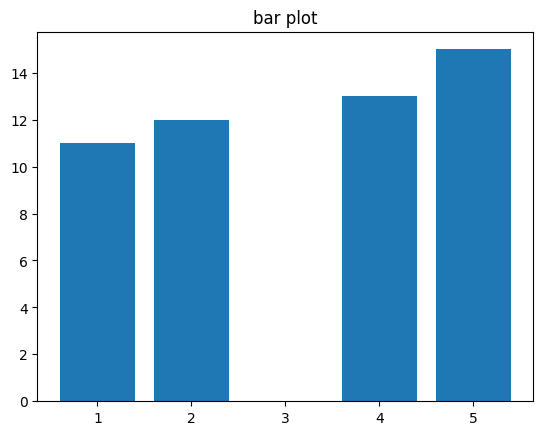

In [ ]:
import matplotlib.pyplot as plt
x=[1,2,4,5]
y=[11,12,13,15]
plt.bar(x,y)
plt.title("bar plot")
plt.show()

In [ ]:
import pandas as pd
data={
    "Name":["Rupa","Anu","Kiran","Rahul"],
    "Marks":[85,90,70,88],
    "City":["Hyderabad","Bangalore","chennai","Delhi"]
}
df= pd.DataFrame(data)
print("Full Data:")
print(df)

print("Average Marks:")
print(df["Marks"].mean())

print("Studens with Marks>80:")
print(df[df["Marks"]>80])

Full Data:
    Name  Marks       City
0   Rupa     85  Hyderabad
1    Anu     90  Bangalore
2  Kiran     70    chennai
3  Rahul     88      Delhi
Average Marks:
83.25
Studens with Marks>80:
    Name  Marks       City
0   Rupa     85  Hyderabad
1    Anu     90  Bangalore
3  Rahul     88      Delhi


In [38]:

import pandas as pd
import plotly.express as px
from datetime import datetime

pd.set_option("display.max_columns",None)
import kagglehub
df=pd.read_csv("/content/netflix_title.csv")
df.head()

df.info()
df.isnull().sum

df['director']=df['director'].fillna("unkown")
df['cast']=df['cast'].fillna("unknown")
df['country']=df['country'].fillna("unknown")
df['rating']=df['rating'].fillna("Not Rated")

df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')

df['year_added']=df['date_added'].dt.year
df['month_added']=df['date_added'].dt.month

df['duration_num']=df['duration'].str.extract(r'(\d+)')
df['duration_num']=pd.to_numeric(df['duration_num'])

df['listed_in']=df['listed_in'].str.split(',')
df['type'].value_counts()

fig=px.pie(df,names='type',title='Distribution of Movies vs Tv shows')
fig.show()
year_data=df['year_added'].value_counts().sort_index()

fig=px.line(x=year_data.index,y=year_data.values,labels={'x':'Year','y':'Count'},title='Number of titles added per year')
fig.show()

top_countries=df['country'].value_counts().head(10)
fig=px.bar(x=top_countries.index,y=top_countries.values,labels={'x':'Country','y=':'Count'},title='Top 10 Countries with the most netflix content')
fig.show()

rating_counts=df['rating'].value_counts()
fig=px.bar(x=rating_counts.index,y=rating_counts.values,labels={'x':'Rating','y':'rating'},title='Distribution of Ratings')
fig.show()

genres=df.explode('listed_in')
top_genres=genres['listed_in'].value_counts().head(10)

fig=px.bar(x=top_genres.index,y=top_genres.values,labels={'x':'Genre','y':'Count'},title='Top 10 Genres with the most netflix content')
fig.show()

india_df=df[df['country'].str.contains('India',na=False)]
india_df.head()

actors=india_df['cast'].str.split(',').explode()
actors=actors.str.strip()
top_actors=actors.value_counts().head(10)
fig=px.bar(x=top_actors.index,y=top_actors.values,labels={'x':'Actors','y':'Count'},title='Top 10 Actors with the most netflix content in India')
fig.show()

df[df['release_year']>2020].head()
df=df[df['release_year']<=2020]
df.head()

df[df['type'] == "Movie"].head()
df=df[df['type']=='Movie']
df.head()

df[(df['country'].str.contains("India",na=False)) & (df['release_year'] >2020)]
df[df['rating'] == "TV-MA"]
df=df[df['rating'] != "TV-MA"]
df.head()

movies = df[df['type'] == "Movie"]
movies['duration_num'].mean()
movies.head()

india_year=india_df['year_added'] .value_counts().sort_index()
fig=px.line(x=india_year.index,y=india_year.values,labels={'x':'Year','y':'Count'},title='Number of movies added in India per year')
fig.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
